# Local-GPU Dataset Build — Pilot Model Comparison

- Coder: Lenin G. Falconi

## Objetivo

Construir un piloto del dataset de preguntas y respuestas sobre robos usando inferencia local en GPU. El notebook permite comparar modelos candidatos antes de ejecutar el procesamiento completo con `scripts/build_dataset_local_gpu.py`.

## Configuracion rapida

Edita **la siguiente celda de codigo** antes de ejecutar cualquier celda que importe `torch` y reinicia el kernel despues de cambiar estos valores:

```python
GPU_IDS = "4,5"
PILOT_MODE = "small_1gpu_pair"
LARGE_MODEL_KEY = "gemma-3-4b-it"
```

`GPU_IDS` contiene los indices **fisicos** de las GPU que se reservaran para esta ejecucion. Por ejemplo, con `GPU_IDS = "4,5"`, el sistema hace este remapeo dentro del notebook:

| GPU fisica | GPU logica visible | Uso |
|---|---|---|
| 4 | `cuda:0` | primera GPU configurada |
| 5 | `cuda:1` | segunda GPU configurada |

Por eso, dentro del codigo se usan los indices logicos `[0]` y `[1]`, no `[4]` y `[5]`. `CUDA_VISIBLE_DEVICES` debe establecerse antes de importar `torch`; por eso es obligatorio reiniciar el kernel despues de cambiar `GPU_IDS` o `PILOT_MODE`.

## Modos disponibles

### 1. `small_1gpu_pair`: comparar dos modelos pequenos

Usa dos modelos al mismo tiempo, uno en cada GPU:

```python
GPU_IDS = "4,5"
PILOT_MODE = "small_1gpu_pair"
```

- Qwen 2.5 3B (`qwen2.5-3b-instruct`) -> GPU logica `cuda:0` -> GPU fisica 4
- Gemma 3 1B (`gemma-3-1b-it`) -> GPU logica `cuda:1` -> GPU fisica 5

Este modo genera un archivo para cada modelo y permite comparar respuestas, respuestas imposibles y longitudes. `LARGE_MODEL_KEY` se ignora en este modo.

### 2. `large_2gpu_single`: probar un solo modelo usando ambas GPU

Elige exactamente uno de estos modelos:

```python
# Qwen 2.5 7B repartido entre las GPU fisicas 4 y 5
GPU_IDS = "4,5"
PILOT_MODE = "large_2gpu_single"
LARGE_MODEL_KEY = "qwen2.5-7b-instruct"
```

```python
# Gemma 3 4B repartido entre las GPU fisicas 4 y 5
GPU_IDS = "4,5"
PILOT_MODE = "large_2gpu_single"
LARGE_MODEL_KEY = "gemma-3-4b-it"
```

En este modo no se asigna Qwen a una GPU y Gemma a la otra. Se carga un unico modelo cuantizado a 4 bits y Transformers lo distribuye equilibradamente entre `cuda:0` y `cuda:1`. Ambos modelos grandes requieren exactamente dos GPU visibles.

## Modelos que se pueden probar

| Clave | Modelo | GPU requeridas | Modo |
|---|---|---:|---|
| `qwen2.5-3b-instruct` | Qwen 2.5 3B Instruct | 1 | `small_1gpu_pair` |
| `gemma-3-1b-it` | Gemma 3 1B IT | 1 | `small_1gpu_pair` |
| `qwen2.5-7b-instruct` | Qwen 2.5 7B Instruct | 2 | `large_2gpu_single` |
| `gemma-3-4b-it` | Gemma 3 4B IT | 2 | `large_2gpu_single` |

Todos se cargan con cuantizacion de 4 bits. La distribucion de los modelos grandes limita inicialmente la memoria a aproximadamente 12 GiB por GPU, para funcionar con tarjetas de 12 GiB y 15 GiB.

## Flujo del notebook

1. Configura `GPU_IDS`, `PILOT_MODE` y, si corresponde, `LARGE_MODEL_KEY`.
2. Reinicia el kernel y ejecuta las celdas en orden.
3. El notebook descarga y filtra los contextos de 82 a 150 palabras.
4. Carga el modelo o los modelos segun el modo seleccionado.
5. Ejecuta el piloto y guarda los resultados JSONL en `dataset/`.
6. En `small_1gpu_pair`, ejecuta la seccion de comparacion. En `large_2gpu_single`, omite esa seccion porque solo compara las salidas del modo de dos modelos.

**Nota:** este notebook debe ejecutarse en la maquina con GPU y acceso al modelo en Hugging Face. No ejecutes la celda de importaciones antes de fijar `CUDA_VISIBLE_DEVICES`.

In [1]:
import os

# Must run BEFORE any `import torch` in this kernel (CUDA_VISIBLE_DEVICES is read once).
# Changing GPU_IDS or PILOT_MODE requires restarting the kernel.
GPU_IDS = "4,5"  # physical GPU ids dedicated to this session, e.g. "0" or "4,5"
PILOT_MODE = "small_1gpu_pair"  # "small_1gpu_pair" (Qwen-3B + Gemma-1B side by side) or "large_2gpu_single"
LARGE_MODEL_KEY = "gemma-3-4b-it"  # used only when PILOT_MODE == "large_2gpu_single": "qwen2.5-7b-instruct" or "gemma-3-4b-it"

os.environ["CUDA_VISIBLE_DEVICES"] = GPU_IDS


In [2]:
# # For local GPU environment
# !pip install "outlines[transformers]==1.3.3" transformers bitsandbytes accelerate datasets huggingface_hub python-dotenv

import os
import sys
from pprint import pprint

import torch

from scripts.local_qa_generation import (  # noqa: E402
    MODEL_REGISTRY,
    PREGUNTAS_COMUNES,
    get_available_devices,
    load_local_model,
    process_full_dataset_local,
    process_single_context_local,
)

/var/lib/datausers_jupyterhub/lfalconi_storage/miniforge3/envs/pyt-eqa-fge/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from dotenv import load_dotenv
from huggingface_hub import login

# Reads HUGGINGFACE_TOKEN from a .env file at the repo root (never commit the token).
load_dotenv()
hf_token = os.getenv("HUGGINGFACE_TOKEN")
if not hf_token:
    raise RuntimeError(
        "HUGGINGFACE_TOKEN not found. Add it to a .env file at the repo root."
    )
login(hf_token)


## 0. Sanity check: is `outlines` installed and working?

Quick standalone check, independent of the GPU models loaded later, so a broken `outlines` install fails fast here instead of deep into section 3/4.

In [4]:
import outlines
from pydantic import BaseModel
from transformers import AutoModelForCausalLM, AutoTokenizer

# print("outlines version:", outlines.__version__)


class _SanityCheckSchema(BaseModel):
    ok: bool


# CPU-only smoke test of schema-constrained generation, no GPU model required.
_sanity_model = outlines.from_transformers(
    AutoModelForCausalLM.from_pretrained("sshleifer/tiny-gpt2"),
    AutoTokenizer.from_pretrained("sshleifer/tiny-gpt2"),
)
_sanity_result = _sanity_model("Reply with JSON.", _SanityCheckSchema)
print("outlines constrained-generation smoke test output:", _sanity_result)

Loading weights: 100%|██████████| 29/29 [00:00<00:00, 15534.46it/s]
[transformers] GPT2LMHeadModel LOAD REPORT from: sshleifer/tiny-gpt2
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
transformer.h.{0, 1}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/var/lib/datausers_jupyterhub/lfalconi_storage/miniforge3/envs/pyt-eqa-fge/lib/python3.11/site-packages/transformers/generation/utils.py:1676: UserWarning: Using the model-agnostic default `max_length` (=24) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


outlines constrained-generation smoke test output: {"ok": false }


## 1. Load raw dataset and apply the same 82–150 word filter

In [5]:
from datasets import load_dataset

MIN_WORDS = 82
MAX_WORDS = 150

dataset_path = "LeninGF/autotrain-data-robberyclassification"
ds = load_dataset(dataset_path)


def count_words(sample):
    sample["word_count"] = len(sample["relato"].split())
    return sample


ds = ds.map(count_words, batched=False)
filtered_ds = ds["train"].filter(
    lambda batch: [MIN_WORDS <= x <= MAX_WORDS for x in batch["word_count"]],
    batched=True,
    batch_size=1000,
)
filtered_ds

Dataset({
    features: ['relato', 'labels', 'word_count'],
    num_rows: 174594
})

## 2. Select a pilot subset


In [6]:
import random

PILOT_SIZE = 50
random.seed(42)  # reproducible pilot sample
pilot_size = min(PILOT_SIZE, len(filtered_ds))
pilot_indices = random.sample(population=range(len(filtered_ds)),
                              k=pilot_size)
pilot_ds = filtered_ds.select(pilot_indices)

pilot_ds

Dataset({
    features: ['relato', 'labels', 'word_count'],
    num_rows: 50
})

## 3. Load candidate models (per `PILOT_MODE`)

- `small_1gpu_pair`: `qwen2.5-3b-instruct` on logical `cuda:0` + `gemma-3-1b-it` on logical `cuda:1`, loaded side by side
- `large_2gpu_single`: `LARGE_MODEL_KEY` (`qwen2.5-7b-instruct` or `gemma-3-4b-it`) alone, balanced across both visible GPUs


In [7]:
devices = get_available_devices()
print(f"Available devices (logical, after CUDA_VISIBLE_DEVICES remap): {devices}")

qwen_model = None
gemma_model = None
large_model = None

if PILOT_MODE == "small_1gpu_pair":
    if len(devices) < 2:
        raise RuntimeError("small_1gpu_pair needs 2 visible GPUs; set GPU_IDS to two ids and restart the kernel.")
    qwen_model = load_local_model("qwen2.5-3b-instruct", gpu_ids=[0], quantize_4bit=True)
    gemma_model = load_local_model("gemma-3-1b-it", gpu_ids=[1], quantize_4bit=True)
elif PILOT_MODE == "large_2gpu_single":
    entry = MODEL_REGISTRY[LARGE_MODEL_KEY]
    if len(devices) != entry["num_gpus"]:
        raise RuntimeError(
            f"{LARGE_MODEL_KEY} needs {entry['num_gpus']} visible GPUs; "
            "set GPU_IDS accordingly and restart the kernel."
        )
    large_model = load_local_model(LARGE_MODEL_KEY, gpu_ids=list(range(len(devices))), quantize_4bit=True)
else:
    raise ValueError(f"Unknown PILOT_MODE '{PILOT_MODE}'")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Available devices (logical, after CUDA_VISIBLE_DEVICES remap): ['cuda:0', 'cuda:1']
Loading Qwen/Qwen2.5-3B-Instruct on logical gpu ids [0] ...


Loading weights: 100%|██████████| 434/434 [00:02<00:00, 151.29it/s]


Loading google/gemma-3-1b-it on logical gpu ids [1] ...


Loading weights: 100%|██████████| 340/340 [00:00<00:00, 430.43it/s]


## 4. Run the pilot generation

- `small_1gpu_pair`: each model writes to its own JSONL file for side-by-side comparison in section 5
- `large_2gpu_single`: runs a 1-context sanity check first for `gemma-3-4b-it` through Gemma's native chat-template/generation path, then the full pilot subset

In [8]:
PILOT_QWEN_FILE = os.path.join("dataset", "pilot_qwen2.5-3b.jsonl")
PILOT_GEMMA_FILE = os.path.join("dataset", "pilot_gemma-3-1b.jsonl")
PILOT_LARGE_FILE = os.path.join("dataset", f"pilot_{LARGE_MODEL_KEY}.jsonl")

if PILOT_MODE == "small_1gpu_pair":
    process_full_dataset_local(
        dataset=pilot_ds,
        output_file=PILOT_QWEN_FILE,
        model=qwen_model,
        questions=PREGUNTAS_COMUNES,
        checkpoint_interval=10,
        id_prefix="pilot_qwen",
        model_name="qwen2.5-3b-instruct",
    )
    process_full_dataset_local(
        dataset=pilot_ds,
        output_file=PILOT_GEMMA_FILE,
        model=gemma_model,
        questions=PREGUNTAS_COMUNES,
        checkpoint_interval=10,
        id_prefix="pilot_gemma",
        model_name="gemma-3-1b-it",
    )
elif PILOT_MODE == "large_2gpu_single":
    if LARGE_MODEL_KEY == "gemma-3-4b-it":
        # Verifica la ruta nativa de Gemma con chat template y model.generate.
        sanity_result = process_single_context_local(
            pilot_ds[0]["relato"],
            PREGUNTAS_COMUNES[:1],
            large_model,
            context_id="sanity_check",
            model_name=LARGE_MODEL_KEY,
        )
        print("Sanity check passed:", sanity_result)

    process_full_dataset_local(
        dataset=pilot_ds,
        output_file=PILOT_LARGE_FILE,
        model=large_model,
        questions=PREGUNTAS_COMUNES,
        checkpoint_interval=10,
        id_prefix=f"pilot_{LARGE_MODEL_KEY}",
        model_name=LARGE_MODEL_KEY,
    )

Checkpoint guardado en contexto 0
Checkpoint guardado en contexto 10
Error (1 validation error for AnswerSchema
  Invalid JSON: EOF while parsing a string at line 1 column 215 [type=json_invalid, input_value='{"answer_text": "mi bill...15 dólares en efectivo', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid), reintentando (1/2)...
Error crítico en contexto 15: Fallo después de 2 reintentos
Checkpoint guardado en contexto 20
Error (1 validation error for AnswerSchema
  Invalid JSON: EOF while parsing a string at line 1 column 167 [type=json_invalid, input_value='{"answer_text": "1 motos...caballo 5 litros de ven', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid), reintentando (1/2)...
Error crítico en contexto 28: Fallo después de 2 reintentos
Checkpoint guardado en contexto 30
Error (1 validation error for AnswerSchema
  Invalid JSON: EOF while parsing a string at line 1 column 197 [type

## 5. Compare pilot output quality

Only applicable when `PILOT_MODE == "small_1gpu_pair"`. Same analysis patterns as `dataset_xplore_and_upload.ipynb`: `impossible_find_answer`/`is_impossible` value counts and answer-length distribution, side by side for the two models.

In [9]:
if PILOT_MODE == "small_1gpu_pair":
    from datasets import load_dataset as load_jsonl_dataset

    df_qwen = load_jsonl_dataset("json", data_files=PILOT_QWEN_FILE, split="train").to_pandas()
    df_gemma = load_jsonl_dataset("json", data_files=PILOT_GEMMA_FILE, split="train").to_pandas()

    for name, df in [("Qwen2.5-3B-Instruct", df_qwen), ("Gemma-3-1B-IT", df_gemma)]:
        df["answer_text_number_words"] = df["answer_text"].apply(lambda x: len(str(x).split()))
        print(f"\n=== {name} ===")
        print(df["impossible_find_answer"].value_counts())
        print(df["answer_text_number_words"].describe())
else:
    print("Comparison skipped: it is only applicable to small_1gpu_pair.")

Generating train split: 235 examples [00:00, 33263.41 examples/s]
Generating train split: 250 examples [00:00, 27686.64 examples/s]


=== Qwen2.5-3B-Instruct ===
impossible_find_answer
True     122
False    113
Name: count, dtype: int64
count    235.000000
mean       3.331915
std        4.404791
min        0.000000
25%        0.000000
50%        2.000000
75%        5.000000
max       31.000000
Name: answer_text_number_words, dtype: float64

=== Gemma-3-1B-IT ===
impossible_find_answer
False    138
True     112
Name: count, dtype: int64
count    250.000000
mean       4.660000
std        3.806621
min        0.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       30.000000
Name: answer_text_number_words, dtype: float64


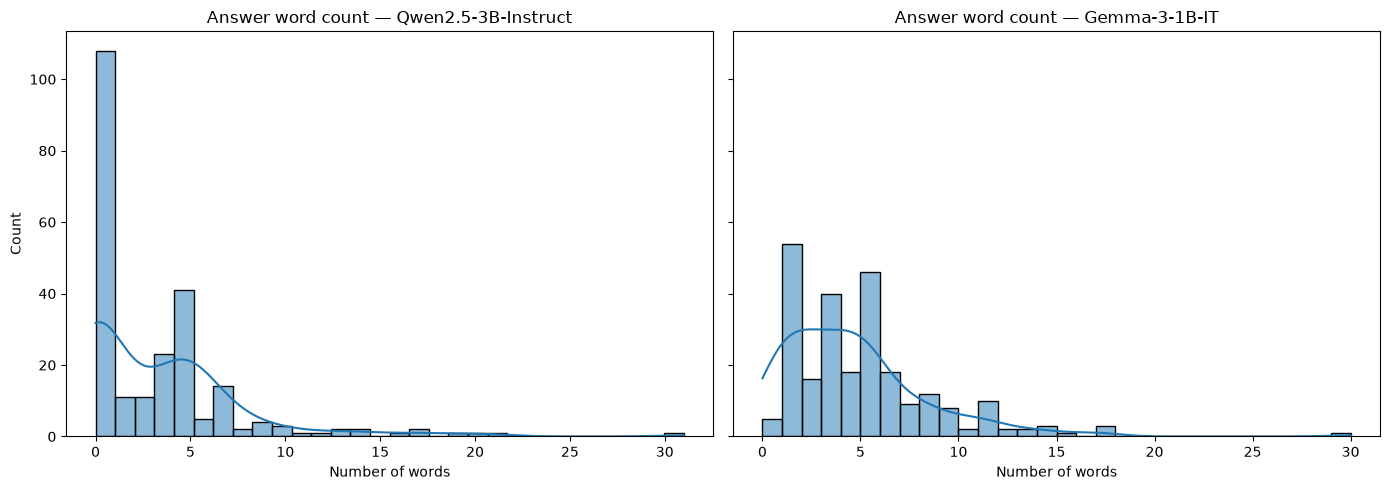

In [12]:
if PILOT_MODE == "small_1gpu_pair":
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, name, df in zip(axes, ["Qwen2.5-3B-Instruct", "Gemma-3-1B-IT"], [df_qwen, df_gemma]):
        sns.histplot(df["answer_text_number_words"], bins=30, kde=True, ax=ax)
        ax.set_title(f"Answer word count — {name}")
        ax.set_xlabel("Number of words")
    plt.tight_layout()
    plt.show()
else:
    print("Histogram skipped: it is only applicable to small_1gpu_pair.")

In [13]:
if PILOT_MODE == "small_1gpu_pair":
    # Spot-check a few samples from each model manually before deciding.
    pprint(df_qwen[["question", "answer_text", "impossible_find_answer"]].sample(5))
    pprint(df_gemma[["question", "answer_text", "impossible_find_answer"]].sample(5))
else:
    print("Spot-check skipped: it is only applicable to small_1gpu_pair.")

                                              question  \
149  ¿Qué valor en dólares tenían los objetos sustr...   
28   ¿En qué dirección o entre qué calles sucedió e...   
120                       ¿Qué objetos fueron robados?   
231                ¿En qué fecha ocurrió el incidente?   
83   ¿En qué dirección o entre qué calles sucedió e...   

                                           answer_text  impossible_find_answer  
149                trescientos dólares aproximadamente                   False  
28                                                                        True  
120  mi motocicleta placas ho356q marca motor uno c...                    True  
231                           01 de septiembre de 2018                   False  
83                                                                        True  
                                              question  \
68   ¿En qué dirección o entre qué calles sucedió e...   
206                ¿En qué fecha ocurrió el incid

## 6. Decision

Fill in after reviewing the pilot results on the GPU machine:

- Winning model for the full run: **TBD**
- Reasoning: **TBD**

Before committing to a full run, compare throughput across model configs with:

```bash
python scripts/benchmark_local_gpu.py --model <qwen2.5-3b-instruct|qwen2.5-7b-instruct|gemma-3-1b-it|gemma-3-4b-it> \
    --gpu-ids <e.g. 0 or 4,5> --num-samples 5
```

Once decided, run the full-scale build with:

```bash
python scripts/build_dataset_local_gpu.py --model <qwen2.5-3b-instruct|qwen2.5-7b-instruct|gemma-3-1b-it|gemma-3-4b-it> \
    --gpu-ids <e.g. 0 or 4,5> --output-file dataset/dataset_squad_v2_localgpu.json
```
